In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# HW3 - Trees on the Titanic

Classify the people in data set and tell me **WHO LIVES AND WHO DIES**.

I given you lots of different example code in the past several tutorials. In this assignment you will have to pull the pieces together and demonstrate that you know what you are doing.  

The key skill in problem solving is the ability to break a complex problem into smaller steps.  In data science this often looks like making test cases that start as simply as possible and gradually add complexity to approach the original problem.  You should be able to confirm that each step works, or to put it another way:
**ALWAYS TEST YOUR CODE IN CASES WHERE YOU KNOW THE RIGHT ANSWER**







# SETUP - DONT CHANGE ANYTHING HERE

## Input
Load and process the input data.  

*Use the code below to load data without modifications.*

In [3]:
# Load Titanic
data = fetch_openml(name="titanic",version=1, as_frame=True, parser='auto')

df_raw = data.frame # the raw data
df_raw.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Reminder from our **Titanic Pandas Tutorial** about some of these columns:

* pclass = Passenger Class 1, 2, or 3
* survived = 1 for people who survived, they will have a lifeboat number in boat and the body column should be blank.  Not all bodies are recovered.
* sibsp = number of siblings (for kids) or spouses (for adults) aboard
* parch = number of parents (for kids) or children (for adults) aboard
* fare is in old British money (pounds / shillings / pence) which gives weird fractions




In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


To use this for machine learning, we need to clean this up significantly:
* Throw away some columns
* Make all columns numeric (everything we use should be *int64* or *float64*)
* Remove rows with missing data


In [5]:
# Factorize any non-numeric columns we want to use
codes, genders = pd.factorize(df_raw.sex)
df_raw['gender'] = codes
print('Gender codes:', genders.categories)

Gender codes: Index(['female', 'male'], dtype='object')


In [6]:
print('Original data:')
print(df_raw.sex.value_counts())

print('\nFactorized result:')
df_raw.gender.value_counts()

Original data:
sex
male      843
female    466
Name: count, dtype: int64

Factorized result:


,count
gender,
1,843
0,466


In [7]:
# Survived is a category, so the values are strings instead of numbers!
df_raw.survived.unique()

['1', '0']
Categories (2, object): ['0', '1']

In [8]:
df_raw.survived = df_raw.survived.astype('int64')

In [9]:
df_raw.survived.unique()  # much better!

array([1, 0])

In [10]:
# Choose columns to keep
df_raw.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest', 'gender'],
      dtype='object')

In [11]:
features = ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare'] # choose columns for features
target = ['survived']
cols = target + features # combination of target and features
df = df_raw[cols].copy()
df.head()

,survived,pclass,gender,age,sibsp,parch,fare
0,1,1,0,29.0000,0,0,211.3375
1,1,1,1,0.9167,1,2,151.5500
2,0,1,0,2.0000,1,2,151.5500
3,0,1,1,30.0000,1,2,151.5500
4,0,1,0,25.0000,1,2,151.5500


In [12]:
df.describe()

,survived,pclass,gender,age,sibsp,parch,fare
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,0.381971,2.294882,0.644003,29.881135,0.498854,0.385027,33.295479
std,0.486055,0.837836,0.478997,14.413500,1.041658,0.865560,51.758668
min,0.000000,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


WARNING!  The count is different for different columns.  We must have some missing data!

In [13]:
# Clean up dataframe by dropping missing rows
print('Row count:\t', len(df))
df.dropna(inplace=True)  # delete rows with missing or bad values
print('After dropna:\t', len(df))

Row count:	 1309
After dropna:	 1045


In [14]:
# Save variables
X = df[features].values
y = df[target].values

In [15]:
print('Feature shape: ', X.shape)
print('Feature names: ', features)

Feature shape:  (1045, 6)
Feature names:  ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare']


## Load passenger data

In [16]:
df_pass = pd.read_csv('https://raw.githubusercontent.com/mdaugherity/MachineLearning2026/refs/heads/main/class/titanic_passengers.csv')
df_pass

,Name,pclass,gender,age,sibsp,parch,fare
0,Jackson,1,1,19,2,2,16
1,Jayden,1,1,91,1,1,74
2,Elliot,2,1,35,3,2,347
3,Barrett,3,1,-1,-1,8,412
4,Michael,1,1,37,1,3,359
5,Andrew,2,1,21,6,3,369
6,Levi,2,1,-101,1,2,324
7,Matthew,3,1,20,6,7,32
8,Musa,3,1,20,4,2,367
9,DrD,1,1,199,1,2,250


In [17]:
X_pred = df_pass[features].values # make sure we get the same feature columns in the same order
X_pred

array([[   1,    1,   19,    2,    2,   16],
       [   1,    1,   91,    1,    1,   74],
       [   2,    1,   35,    3,    2,  347],
       [   3,    1,   -1,   -1,    8,  412],
       [   1,    1,   37,    1,    3,  359],
       [   2,    1,   21,    6,    3,  369],
       [   2,    1, -101,    1,    2,  324],
       [   3,    1,   20,    6,    7,   32],
       [   3,    1,   20,    4,    2,  367],
       [   1,    1,  199,    1,    2,  250]])

# Problems - Your Work Goes Here
These problems are meant to be fairly short, so there are several of them...

## Problem 0 - Test Cases
Validate your code with these tests:
 * Make a new variable called ```X2``` with only age and fare columns.  
 * Train a tree using all rows of ```X2``` and ```y``` with max_depth=2
 * Print a nice diagram of the tree.  Make sure it is filled and all features and classes are labeled!
 * Make a plot of the decision boundaries and verify it matches the diagram


In [18]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['tab:orange','tab:blue'])
cmap_light = ListedColormap(['bisque','lightsteelblue'])

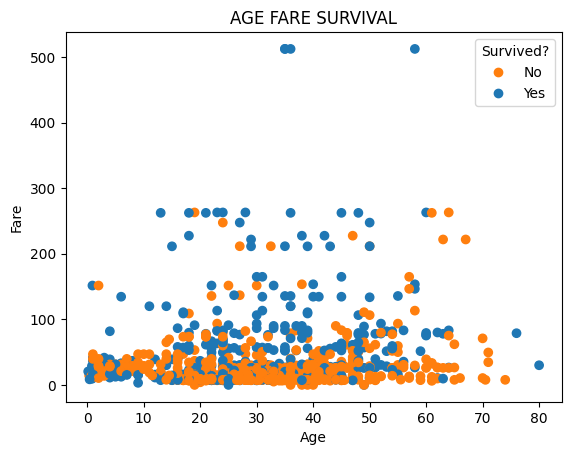

In [19]:
X2 = df[['age', 'fare']].copy()
y = df['survived']

plt.figure()
scatter = plt.scatter(X2['age'], X2['fare'], c=y, cmap=cmap_bold)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("AGE FARE SURVIVAL")
handles, _ = scatter.legend_elements()
plt.legend(handles, ["No", "Yes"], title="Survived?")
plt.show()

In [20]:
dt_classifier = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_classifier.fit(X2, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [21]:
from sklearn.tree import plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

def make_tree_plots(X, y, depth):
  """Makes a new tree of a fixed depth, then plots the tree structure and decision boundary"""
  plt.figure(figsize=(14,6))

  plt.subplot(1,2,1)
  clf = DecisionTreeClassifier(max_depth=depth,random_state=1) # setting random state to get the result I want
  clf.fit(X, y)
  plot_tree(clf, filled=True, class_names=['Died','Survived'])

  ax = plt.subplot(1,2,2)
  DecisionBoundaryDisplay.from_estimator(clf, X,cmap=cmap_light, grid_resolution=200, ax=ax)
  plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=cmap_bold,edgecolor='k', s=20)
  plt.xlabel(X.columns[0])
  plt.ylabel(X.columns[1])
  plt.title("Decision Boundary")

  plt.show()

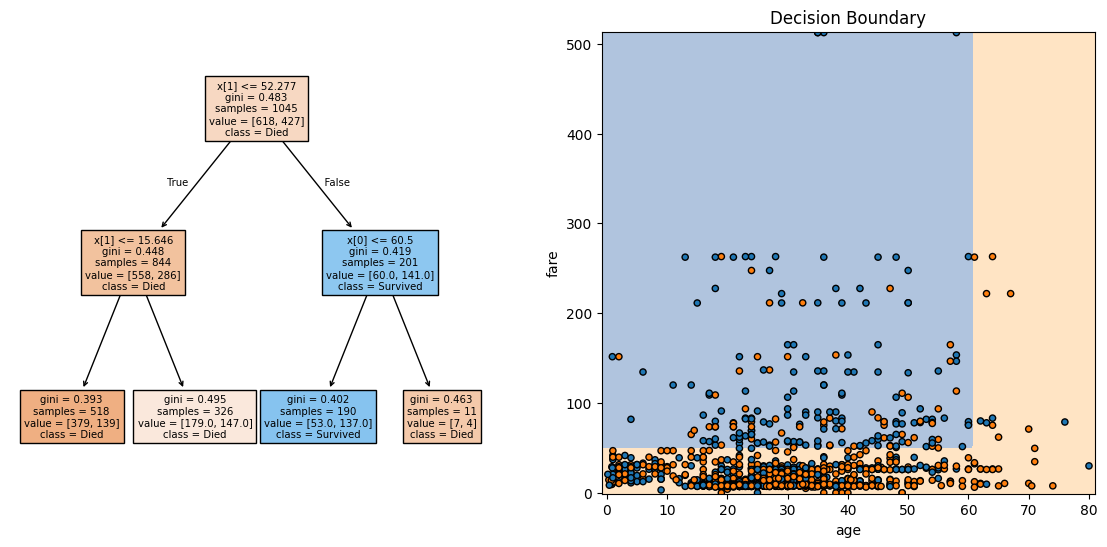

In [22]:
make_tree_plots(X2, y, 2)

# Problem 1 - Tree Training
Using all 6 features, find the optimal value of max_depth and the test score for a DecisionTreeClassifier.

In [23]:
idx = df.index.to_numpy()
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, stratify=y, random_state=0
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (783, 6)
X_test shape: (262, 6)
y_train shape: (783,)
y_test shape: (262,)


In [24]:
def make_grid_plot_labels(grid_clf):
  # Turns a parameter dictionary entry into a single string and returns the whole list
  res = grid_clf.cv_results_
  NUM_KEYS = len(res['params'][0].values())
  labels = []
  for item in res['params']:
    labels.append("_".join( [str(val) for val in item.values()]))
  return labels

def make_grid_plot(grid_clf):
  # Displays the scores for every set of parameters
  res = grid_clf.cv_results_
  plt.figure(figsize=(8,4))
  plt.axvline(grid_clf.best_index_, color='black', lw=2) # draw black line behind best params

  NUM_KEYS = len(res['params'])
  x = np.arange(NUM_KEYS)
  plt.plot(res['mean_test_score'],'-o', label='Val')
  plt.fill_between(x,res['mean_test_score']+res['std_test_score'], res['mean_test_score']-res['std_test_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_test_score'],yerr=res['std_test_score'],xerr=0,fmt='-o', capsize=2, label='Val')

  plt.plot(res['mean_train_score'],'-s', label='Train')
  plt.fill_between(x,res['mean_train_score']+res['std_train_score'], res['mean_train_score']-res['std_train_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_train_score'],yerr=res['std_train_score'],xerr=0,fmt='-s', capsize=2,label='Train')
  plt.title('Grid CV Results')
  plt.ylabel('Mean Test Score')

  labels = make_grid_plot_labels(grid_clf)
  plt.xticks(ticks = x, labels=labels, rotation=90)
  plt.legend()
  plt.grid()
  plt.show()

Grid Parameters: {'clf__max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])}


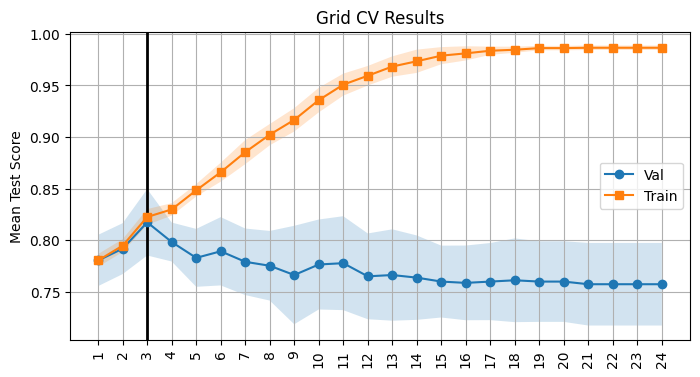

Best parameters: {'clf__max_depth': np.int64(3)}
Best Validation Score:	0.817


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=0)) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
DEPTHS = np.arange(1,25)
params = {'clf__max_depth':DEPTHS}
print('Grid Parameters:',params)

dt_grid = GridSearchCV(pipe, param_grid=params, return_train_score=True)
dt_grid.fit(X_train, y_train.ravel())

make_grid_plot(dt_grid)

dt_test_score = dt_grid.score(X_test, y_test.ravel())
print('Best parameters:', dt_grid.best_params_)
print(f"Best Validation Score:	{dt_grid.best_score_:0.3f}")
print(f"Test Score:		{dt_test_score:0.3f}")


# Problem 2 - The Nearest Other Clasifier
Train a nearest neighbors classifier on the same data from problem 1 (all 6 features).  Clearly report the optimal parameters along with the train and test scores

Grid Parameters: {'clf__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), 'clf__weights': ['uniform']}


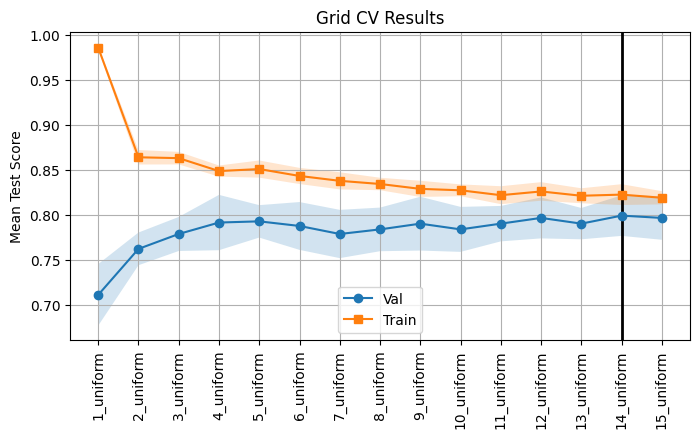

Best parameters: {'clf__n_neighbors': np.int64(14), 'clf__weights': 'uniform'}
Best Validation Score:	0.799


In [26]:
from sklearn.neighbors import KNeighborsClassifier

# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', KNeighborsClassifier()) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
KLIST = np.arange(1,16)
WLIST = ['uniform']
params = {'clf__n_neighbors':KLIST, 'clf__weights':WLIST}
print('Grid Parameters:',params)

knn_grid = GridSearchCV(pipe, param_grid=params, return_train_score=True)
knn_grid.fit(X_train, y_train.ravel())

make_grid_plot(knn_grid)

knn_test_score = knn_grid.score(X_test, y_test.ravel())
print('Best parameters:', knn_grid.best_params_)
print(f"Best Validation Score:	{knn_grid.best_score_:0.3f}")
print(f"Test Score:		{knn_test_score:0.3f}")


# Problem 3 - Thinking
Is the decision tree or neighbors classifier better on this dataset?  **Explain and justify your answer.**

The decision tree has the better score on this split, so it is the better classifier here. It can also represent nonlinear feature interactions directly, which seems to fit this Titanic dataset well.


# Problem 4 - Predictions
Use the best classifier to classify the extra passengers.

In [30]:
# Pick the better model from Problems 1 and 2
if dt_grid.best_score_ >= knn_grid.best_score_:
    best_model = dt_grid.best_estimator_
    best_name = 'Decision Tree'
else:
    best_model = knn_grid.best_estimator_
    best_name = 'KNN'

predictions = best_model.predict(X_pred)

df_pass['survived'] = predictions.astype(int)

print(f"Using best classifier: {best_name}")
print("Extra passengers:")
print(df_pass[['Name', 'survived']])


Extra passengers:
      Name  survived
0  Jackson         0
1   Jayden         0
2   Elliot         0
3  Barrett         1
4  Michael         0
5   Andrew         0
6     Levi         1
7  Matthew         0
8     Musa         0
9      DrD         0


# Problem 5 - Won't You Be My Neighbor
Determine which real Titanic passenger is most similar to "you" (i.e. your entry in the dataset) and print our their info.

In [36]:
barrett_features = df_pass[df_pass['Name'] == 'Barrett'][features].values

best_knn_estimator = knn_grid.best_estimator_.named_steps['clf']
scaler = knn_grid.best_estimator_.named_steps['scaler']
scaled_barrett_features = scaler.transform(barrett_features)

dist, ind = best_knn_estimator.kneighbors(scaled_barrett_features, n_neighbors=1, return_distance=True)
closest_train_row = idx_train[ind[0][0]]

np.set_printoptions(precision=3)
print("Barrett's features:")
print(barrett_features)

print("Most similar real Titanic passenger to Barrett:")
print(df.loc[[closest_train_row]])
print(f"Distance: {dist[0][0]:0.3f}")


Barrett's features:
[[  3   1  -1  -1   8 412]]
Most similar real Titanic passenger to Barrett:
    survived  pclass  gender   age  sibsp  parch     fare
11         1       1       0  18.0      1      0  227.525


# Problem 6 - The Important One
Finally, we see that age, passenger class, ticket fare, and gender are all important factors in determining survival.  **Which single factor is most important?**  Justify and explain your answer.



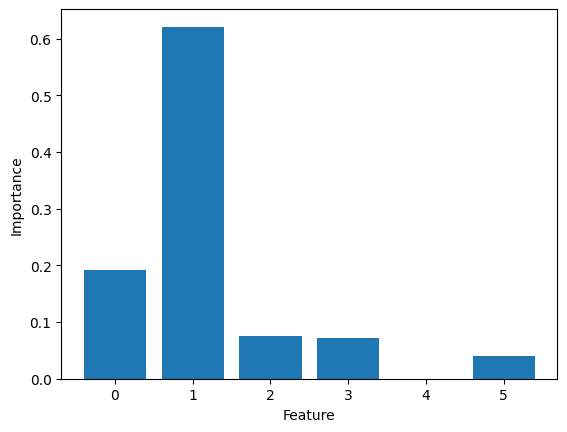

Feature Importances:
pclass    0.192573
gender    0.620789
age       0.075540
sibsp     0.071211
parch     0.000000
fare      0.039886
dtype: float64

The most important factor in determining survival is: GENDER
I think this is likely because of the women and children first policy of saving survivors from the sinking ship


In [49]:
decisiontree = DecisionTreeClassifier(max_depth=dt_grid.best_params_['clf__max_depth'], random_state=0)
decisiontree.fit(X_train, y_train.ravel())

importances = decisiontree.feature_importances_
feature_importances = pd.Series(importances, index=features)

plt.bar([x for x in range(len(importances))], importances)
plt.xticks(range(len(features)), features, rotation=45)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importances:")
print(feature_importances.sort_values(ascending=False))

most_important_factor = feature_importances.idxmax()
print(f"\nThe most important factor in determining survival is: {most_important_factor.upper()}")
print("This is likely related to priority rescue patterns and class-based access to lifeboats.")
